# Assignment 1
Part 1;
Plot a seismic reflection with z0=200m,dt=0.004s, vel=1500m/s. \
Assume your wavelet is full-band (spike).\
Then plot its FK amplitude spectrum (average for all traces) and its FK spectrum.\
The fk_spectrum function is given, you can use a linear event to test that it works.\

Par 2: add 3 reflectors these parameters:\
velocities(rms)=[1500, 2000, 2500]\
depth=[200,500,1070]\
reflectors=[1,-0.5,0.4]\
Set different depth in a list, and loop through its elements.\
You can calculate the Velocities at each reflector by using Vrms from Vinterval (better) or just give yourself some Vrms directly.


In [83]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
dh=20
nh=64
hmin=nh/2*dh
hh=np.arange(nh)*dh-hmin
vel=1500
z=200
dist=[np.sqrt(x*x+4*z*z) for x in hh]
t=np.array(dist)/vel

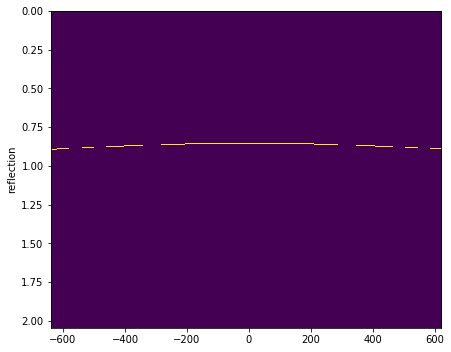

In [133]:
nt=512
dt=0.004
data=np.zeros((nt,nh))
tmax=nt*dt;
for ih in range(nh):
    it=int(t[ih]/dt)
    if ((it>=0)|(it<nt)):        
        data[it,ih]+=1;

tt=np.arange(nt)*dt;
fig,axes=plt.subplots(figsize=(7,7))
axes.imshow(data,extent=[np.min(hh),np.max(hh),np.max(tt),np.min(tt)], aspect=500)
plt.ylabel('reflection')
plt.show()

In [134]:
nt=512
dt=0.004
data=np.zeros((nt,nh))
tmax=nt*dt;
vel=[1500, 2000, 2500]
z=[200,500,1070]
r=[1,-0.5,0.4]
for iz in range(len(z)):
    dist=[np.sqrt(x*x+4*z[iz]*z[iz]) for x in hh]
    t=np.array(dist)/vel[iz]
    for ih in range(nh):
        it=int(t[ih]/dt)
        if ((it>=0)|(it<nt)):        
            data[it,ih]+=r[iz];

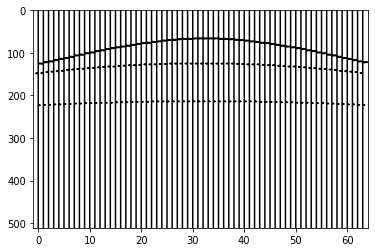

In [135]:
from wiggle.wiggle import wiggle
wiggle(data, sf= 0.05)

In [136]:
def fk_spectrum(d,dt,dx,freq_cut=0):
    if (freq_cut==0):
        freq_cut=int(1/(2*dt)-1)
    
    nt,nx=d.shape
    nf=np.int(2 ** (np.ceil(np.log2(nt)) + 1))
    nkx=np.int(2 ** (np.ceil(np.log2(nx + 2)) + 1))
    
    d_fk=np.real(np.fft.fftshift(np.fft.fft2(d,(nf,nkx))))
    d_fk=d_fk / np.max(d_fk)
    
    nf2=nf / 2 + 2
    ifreq=np.arange(1,nf+1)
    ifreq2=ifreq - 1 - nf*np.floor(ifreq/nf2)
    freq=ifreq2 / nf / dt
    
    nkx2=nkx / 2 + 2
    ikx=np.arange(1,nkx+1)
    ikx2=ikx - 1 - nkx*np.floor(ikx / nkx2)
    kx2=ikx2 / nkx / dx
    kx=np.hstack((kx2[np.int(nkx/2+2):nkx],kx2[0:np.int(nkx/2+2)]))
    
    if (freq_cut > 0):
        dfreq=1 / nf / dt
        ifreq_cut=np.int(round(freq_cut / dfreq) + 1)
        freq=freq[range(ifreq_cut)]
        d_fk=d_fk[np.arange(np.int(nf/2),np.int(nf/2+ifreq_cut)),:]
        
    return d_fk,freq,kx

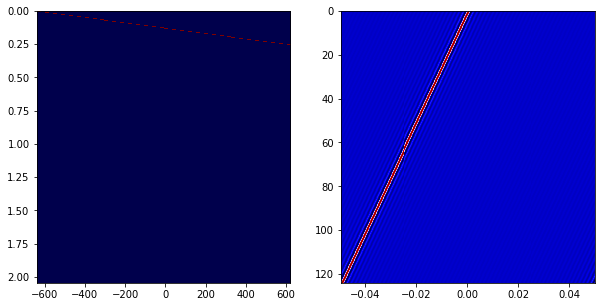

In [137]:
# test fk_spectrum
datatest=np.eye(nt,nh)
dt=0.004
dx=10
d_fk,freq,kx=fk_spectrum(datatest,dt,dx)
plt.figure(figsize=(10,5))
plt.subplot(121),
plt.imshow(datatest,extent=[np.min(hh),np.max(hh),np.max(tt),np.min(tt)], aspect='auto',cmap ='seismic')
plt.subplot(122)
plt.imshow(d_fk,extent=[np.min(kx),np.max(kx),np.max(freq),np.min(freq)], aspect='auto',cmap='seismic')

In [138]:
dt=0.004
dx=10
d_fk,freq,kx=fk_spectrum(data,dt,dx)

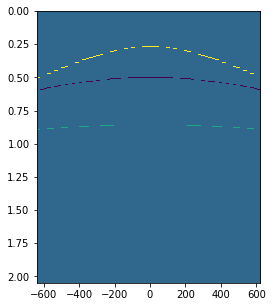

In [139]:
plt.figure(figsize=(4,5))
plt.imshow(data,extent=[np.min(hh),np.max(hh),tmax,0],aspect='auto')


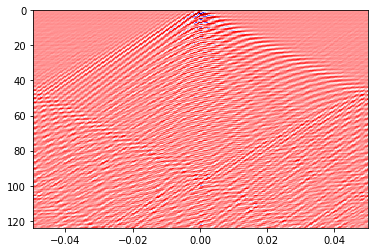

In [140]:
plt.imshow(d_fk, extent=[np.min(kx),np.max(kx),np.max(freq),np.min(freq)], aspect='auto',cmap='seismic')

# Create a data fitting example
Use LS to fit a straight line to the following data. \
First use sklearn for comparison, then use np.linalg package to solve the problem with np matrices. 

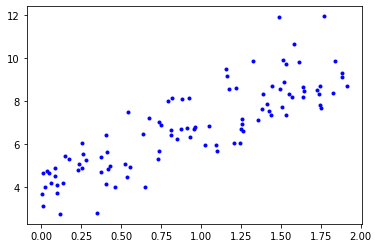

In [141]:
from sklearn.linear_model import LinearRegression
import numpy as np
import matplotlib.pyplot as plt
x = 2*np.random.rand(100,1)
y=4+3*x+np.random.randn(100,1)
plt.plot(x,y,'b.')

For comparison, here is the problem solved using sklearn:

[4.0995578] [[2.86037573]]


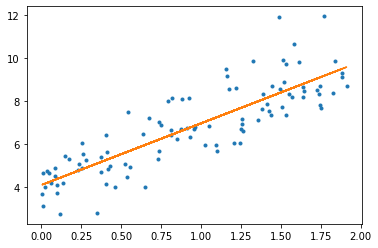

In [142]:
lin_reg=LinearRegression()
lin_reg.fit(x,y)
print(lin_reg.intercept_,lin_reg.coef_)
xn=x;
lin_reg.predict(xn)
yn=lin_reg.predict(xn)
plt.plot(x,y,'.',xn,yn)
plt.show()

Now solve using matrices and standard LS.

[[4.0995578 ]
 [2.86037573]]


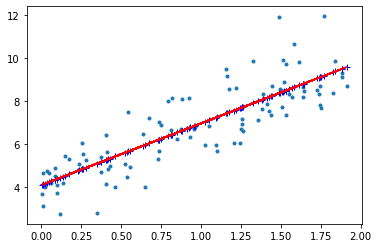

In [143]:
#use standard LS
x_b=np.c_[np.ones((100,1)),x]
x_b.shape
x.shape

theta_best=np.linalg.inv(x_b.T.dot(x_b)).dot(x_b.T).dot(y)
print(theta_best)

yls=x_b.dot(theta_best)
plt.plot(x,y,'.',x,yn,'b+',x,yls,'r')
plt.show()

## Create a seismic trace
create a seismic trace using a synthetic reflectivity function and a Ricker wavelet.\
You can calculate the Ricker wavelet using the original equation or from scipy \
* from scipy import signal
* ricker=signal.ricker(nt,amp)
// create your reflectivity
* trace =signal.convolve(ricker, reflectivity, mode='same')

Optional: can you do this for every trace on the original gather you created before?

In [239]:
#my arbitrary choices for R, x, dx
R=[0.1,-0.05,0.07,0]
z=[200,500,1070,1600] # depth
vel=[1500,2000,2500,3000]
nz=len(z)
h=[z[i]-z[i-1] for i in range(1,4)]
h.append(z[-1]+1000)
print(len(h),len(R),len(z),len(vel))

4 4 4 4


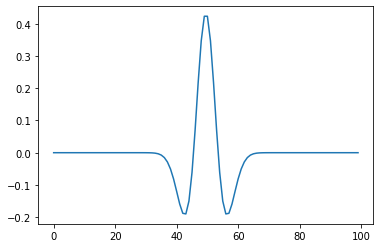

In [240]:
from scipy import signal
points = 100
a = 4.0
wavelet = signal.ricker(points, a)
plt.plot(wavelet)
plt.show()

In [241]:
#imitating code from lab 4 goph 559
def reflectivity(vel,h,R,dt):
    nzeros = round((h/vel)/dt) #number of time samples with r = 0 above the reflector
    r =np.zeros([nzeros,1])
    r[-1] = R #r(end) = Reflectivity
    return r


0.1
-0.05
0.07
0
490


Text(0, 0.5, 'time (s)')

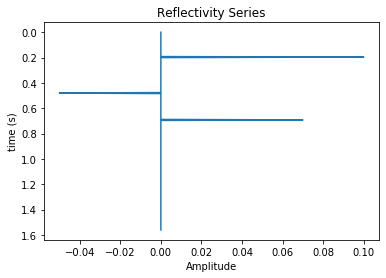

In [267]:
rseries=reflectivity(vel[0],h[0],R[0],dt)
print(R[0])
for i in range(1,len(vel)):
    print(R[i])
    r = reflectivity(vel[i],h[i],R[i],dt) #should have a 1d reflectivity in time with sample dt, like [0, 0, 0, 0, 0, 0, 0, 0, R]
    rseries = np.concatenate((rseries,r)) #make time sample -reflectivity series

#Plot Reflectivity
#make time axis using length of reflectivity series
raxis=np.arange(0,len(rseries))
raxis=raxis*dt
print(len(taxis))
plt.plot(rseries,raxis)
plt.gca().invert_yaxis()
plt.title('Reflectivity Series')
plt.xlabel('Amplitude')
plt.ylabel('time (s)')

In [268]:
print(wavelet.shape,rseries.shape)

(100,) (391, 1)


The convolution between the wavelet and a reflectivity can be done with:

(490,) (490,)


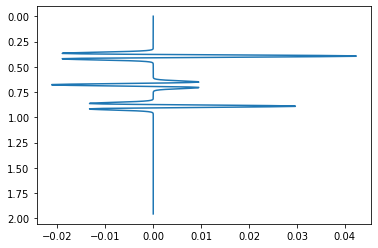

In [269]:
x=signal.convolve(wavelet, rseries.ravel(), mode='full')
taxis=np.arange(0,len(x))
taxis=taxis*dt
print(taxis.shape,x.shape)
plt.plot(x,taxis)
plt.gca().invert_yaxis()

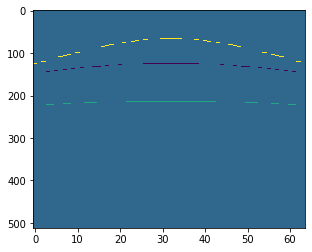

In [271]:
plt.imshow(data, aspect=.1)

In [183]:
dataw=signal.convolve(data,wavelet[:,np.newaxis],mode='same')

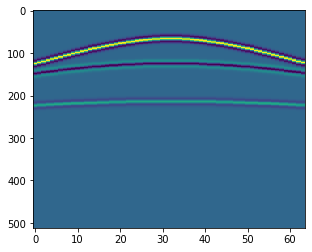

In [184]:
plt.imshow(dataw, aspect=.1)

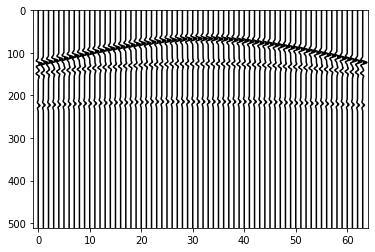

In [185]:
wiggle(dataw, sf= 0.1)

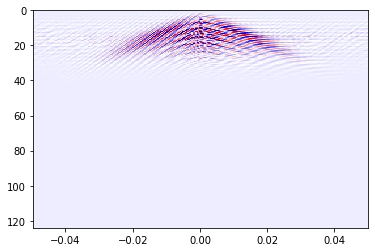

In [186]:
dt=0.004
dx=10
d_fk,freq,kx=fk_spectrum(dataw,dt,dx)
plt.imshow(d_fk, extent=[np.min(kx),np.max(kx),np.max(freq),np.min(freq)], aspect='auto',cmap='seismic')

## Deconvolve:
This part is tricky with scipy, better to use a classical way

In [187]:
from scipy.fft import fft, ifft
def mydeconv(a,b,nn,reg=1e-5):
    A = fft(a,nn)
    B = fft(b,nn)
    C = (np.conj(B)*A)/(np.conj(B)*B+reg)
    c = np.real(ifft(C))
    return c

(512, 64)
(100,)
(611,)
(512,)


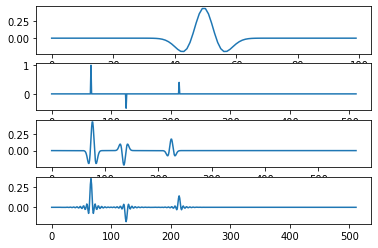

In [194]:

nn=512
print(data.shape)
print(wavelet.shape)
r0=data[:,30]; ## pick an arbitrary trace in the middle

tr =signal.convolve(r0,wavelet,'full');
trd = mydeconv(tr,wavelet,nn)
print(tr.shape)
print(trd.shape)
plt.figure()
plt.subplot(411),plt.plot(wavelet)
plt.subplot(412),plt.plot(r0)
plt.subplot(413),plt.plot(tr[39:])
plt.subplot(414),plt.plot(trd);

In [195]:
dataw = signal.convolve(data,wavelet[:,np.newaxis],'same')
print(dataw.shape,wavelet2.shape)

(512, 64) (100, 1)


In [196]:
datad=np.zeros(dataw.shape)
for i in range(64):    
    datad[:,i]=mydeconv(dataw[:,i],wavelet,nn,1e-11)
    

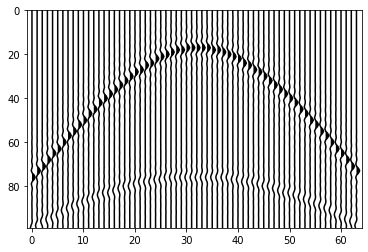

In [197]:
wiggle(datad[:100,:],sf=.1)

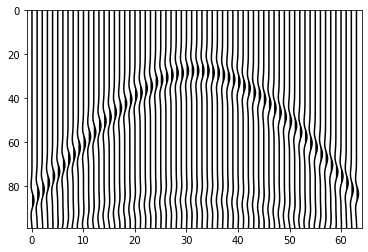

In [198]:
wiggle(dataw[39:139,:],sf=.1)